In [2]:
# part 4 - Quantum Phase Estimation
# estimates phase associated with an eigenvector of a unitary operator

# If needed in a fresh environment:
# pip install qiskit qiskit-aer matplotlib pylatexenc

import qiskit
print(qiskit.__version__)

2.5.0


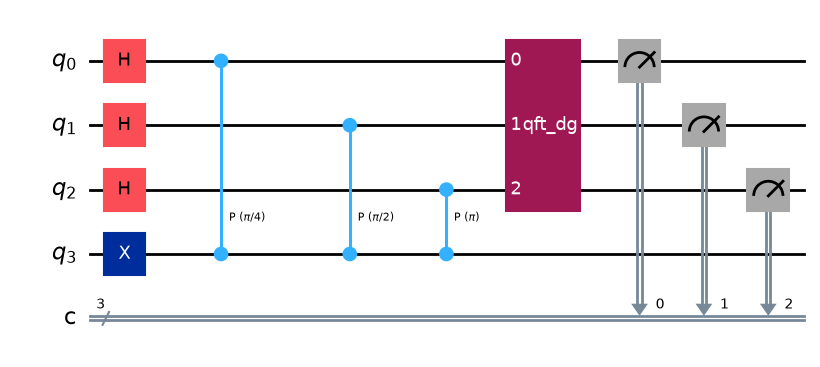

In [29]:
from math import pi

from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseGate, phase_estimation, QFT


num_counting_qubits = 3
system_qubits = 1

# The phase gate P(pi/4) has eigenvalue exp(i*pi/4) on |1>.
# Since exp(i*pi/4) = exp(2*pi*i*(1/8)), the true phase is 1/8.
unitary = PhaseGate(pi / 4)

# Qiskit's modern circuit-library function builds the QPE circuit.
qpe = phase_estimation(num_counting_qubits, unitary)

# Total circuit: counting register + one system qubit + classical bits for counting output.
qc = QuantumCircuit(num_counting_qubits + system_qubits, num_counting_qubits)

# Prepare the system register in the eigenstate |1>.
system_qubit_index = num_counting_qubits
qc.x(system_qubit_index)

# Apply QPE. The QPE circuit acts on counting qubits first, then the system qubit.
qc.compose(qpe, qubits=range(num_counting_qubits + system_qubits), inplace=True)

# FIX THE CURRENT IMPLEMENTATION BY REMOVING THE UNNECESSARY PERM GATE
qc.data.pop()
               
# Measure only the counting register.
qc.measure(range(num_counting_qubits), range(num_counting_qubits))

qc.draw('mpl', style='iqp')

{'001': 1024}


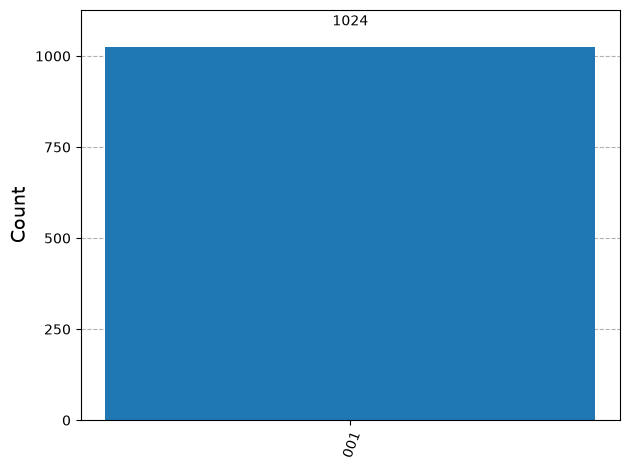

In [30]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)

job = simulator.run(compiled_qc, shots=1024)
result = job.result()
counts = result.get_counts(compiled_qc)

print(counts)
plot_histogram(counts) # note: lesson example seems to have it backwards

In [31]:
def estimate_phase_from_counts(counts, num_counting_qubits):
    most_likely_bitstring = max(counts, key=counts.get)
    integer_value = int(most_likely_bitstring, 2)
    phase_estimate = integer_value / (2 ** num_counting_qubits)

    return most_likely_bitstring, integer_value, phase_estimate

bitstring, integer_value, phase = estimate_phase_from_counts(counts, num_counting_qubits)

print('Most likely bitstring:', bitstring)
print('Integer value:', integer_value)
print('Estimated phase:', phase)
print('Expected phase:', 1 / 8)

Most likely bitstring: 001
Integer value: 1
Estimated phase: 0.125
Expected phase: 0.125


In [37]:
# full example
# Quantum Phase Estimation with modern Qiskit
# Example: estimate the phase of P(pi/4) on eigenstate |1>

from math import pi

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PhaseGate, phase_estimation
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# --------------------------------------------------
# 1. Choose the problem
# --------------------------------------------------

num_counting_qubits = 4
system_qubits = 1
true_phase = 1 / 4

# P(pi/4)|1> = exp(i*pi/4)|1> = exp(2*pi*i*(1/8))|1>
# practice task: # P(pi/2)|1> = exp(i*pi/2)|1> = exp(2*pi*i*(1/4))|1>
unitary = PhaseGate(pi / 2)
#unitary = PhaseGate(2 * pi / 3)

# --------------------------------------------------
# 2. Build the QPE circuit
# --------------------------------------------------

qpe = phase_estimation(num_counting_qubits, unitary)
qc = QuantumCircuit(num_counting_qubits + system_qubits, num_counting_qubits)

# Prepare eigenstate |1> on the system qubit.
system_qubit_index = num_counting_qubits
qc.x(system_qubit_index)

# Apply QPE.
qc.compose(qpe, qubits=range(num_counting_qubits + system_qubits), inplace=True)

# FIX THE CURRENT IMPLEMENTATION BY REMOVING THE UNNECESSARY PERM GATE
qc.data.pop()

# Measure the counting register.
qc.measure(range(num_counting_qubits), range(num_counting_qubits))

# --------------------------------------------------
# 3. Run the circuit on an ideal local simulator
# --------------------------------------------------

simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
job = simulator.run(compiled_qc, shots=1024)
result = job.result()
counts = result.get_counts(compiled_qc)

print('Measurement counts:')
print(counts)
plot_histogram(counts)

# --------------------------------------------------
# 4. Convert the most likely bitstring into a phase
# --------------------------------------------------

most_likely = max(counts, key=counts.get)
integer_value = int(most_likely, 2)
phase_estimate = integer_value / (2 ** num_counting_qubits)

print('Most likely bitstring:', most_likely)
print('Integer value:', integer_value)
print('Estimated phase:', phase_estimate)
print('Expected phase:', true_phase)

Measurement counts:
{'0100': 1024}
Most likely bitstring: 0100
Integer value: 4
Estimated phase: 0.25
Expected phase: 0.25


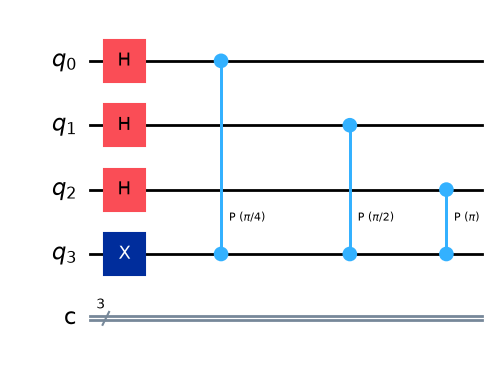

In [14]:
# from math import pi MANUAL VER

# from qiskit import QuantumCircuit

# num_counting_qubits = 3
# theta = pi / 4
# system_qubit_index = num_counting_qubits

# manual_qc = QuantumCircuit(num_counting_qubits + 1, num_counting_qubits)

# # Prepare eigenstate |1>.
# manual_qc.x(system_qubit_index)

# # Create superposition on the counting register.
# for q in range(num_counting_qubits):
#     manual_qc.h(q)

# # Apply controlled powers of P(theta).
# for q in range(num_counting_qubits):
#     power = 2 ** q
#     manual_qc.cp(power * theta, q, system_qubit_index)

# # Append the inverse QFT using the circuit-library QPE construction is usually safer.
# # For full production code, prefer phase_estimation(...) as shown above.
# manual_qc.draw('mpl', style='iqp')

In [38]:
# If needed:
# pip install qiskit-ibm-runtime

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# Save your token once in a secure local environment, then use QiskitRuntimeService()
# QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_IBM_QUANTUM_TOKEN')

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print('Selected backend:', backend.name)

# Convert the circuit to an ISA-compatible circuit for the selected backend.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

sampler = Sampler(backend)
job = sampler.run([isa_qc], shots=4096)
print('Job ID:', job.job_id())

result = job.result()
counts = result[0].data.c.get_counts()
print(counts)

Selected backend: ibm_kingston
Job ID: d9c66pvngvls73a923hg
{'0100': 3231, '0000': 154, '0010': 86, '0110': 111, '1100': 158, '1000': 103, '0101': 92, '1101': 35, '1001': 16, '1110': 25, '1010': 29, '0011': 17, '0001': 12, '1111': 13, '0111': 5, '1011': 9}


In [39]:
most_likely = max(counts, key=counts.get)
integer_value = int(most_likely, 2)
phase_estimate = integer_value / (2 ** num_counting_qubits)

print('Most likely bitstring:', most_likely)
print('Integer value:', integer_value)
print('Estimated phase:', phase_estimate)
print('Expected phase:', true_phase)
# hardware is interestingly, still accurate, but the shots def produced more inconsistent counts

Most likely bitstring: 0100
Integer value: 4
Estimated phase: 0.25
Expected phase: 0.25
